## Fragmentación y conectividad boscosa de los paisajes cafetaleros en la Zona de los Santos

### Introducción 

Esta investigación se realiza bajo el marco de investigacion cuantitativa para determinar los cambios en uso y cobertura de la tierra en la Zona de los Santos. Estudios previos documentan, entre 1984 y 2014, una expansión sostenida de la caficultura y un aumento de la cobertura forestal total, pero también advierten un mayor aislamiento de los remanentes boscosos como consecuencia del avance del monocultivo cafetalero, especialmente en zonas bajas de mayor aptitud agrícola (Arias Salazar & Corrales León, 2017; Consejo Territorial de Desarrollo Rural Los Santos, 2016).

En el presente estudio se exploro como la pérdida de cobertura arbórea reduce y separa los parches de bosque, por lo que es un indicador indirecto de la fragmentación del paisaje. Este cuaderno analiza esa pérdida en tres cantones de la Zona de los Santos, en la provincia de San José: Dota, León Cortés Castro y Tarrazú. Para ello se usan tablas de datos con pandas y gráficos con matplotlib.

**Preguntas que se responden:**

1. ¿Qué cantón perdió más superficie de cobertura arbórea entre 2001 y 2025, y cuál perdió la mayor proporción de la que tenía en el año 2000?
2. ¿Cómo evolucionó la pérdida anual de cobertura arbórea en cada cantón durante el periodo?
3. ¿Cómo se distribuye la pérdida anual y existen años con pérdidas excepcionalmente altas?

**Variables principales:**

| Variable | Descripción | Unidad |
|---|---|---|
| `canton` | Cantón analizado (Dota, León Cortés, Tarrazú) | Texto |
| `anio` | Año en que ocurrió la pérdida, de 2001 a 2025 | Año |
| `perdida_ha` | Superficie de cobertura arbórea perdida en ese año | Hectáreas (ha) |
| `cobertura_2000_ha` | Cobertura arbórea del cantón en el año 2000, usada como punto de partida | Hectáreas (ha) |

La pérdida es bruta: no descuenta la cobertura que pudo recuperarse en el mismo periodo.




In [72]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm

In [110]:
# Dirección del repositorio con los datos de Global Nature Watch
DATOS = "https://raw.githubusercontent.com/Gittorres2000/Fragmentacion_Conectividad_Visual_Studio/main"

# Carga de la pérdida de cobertura arbórea de cada cantón
loss_dota = pd.read_csv(DATOS + "/treecover_loss_dota__ha.csv")
loss_leon = pd.read_csv(DATOS + "/treecover_loss_leon_cortez_ha.csv")
loss_tarrazu = pd.read_csv(DATOS + "/treecover_loss_tarrazu_ha.csv")

# Carga de la extensión de cobertura arbórea (año 2000) de cada cantón
ext_dota = pd.read_csv(DATOS + "/treecover_extent_dota_ha.csv")
ext_leon = pd.read_csv(DATOS + "/treecover_extent_leon_cortez_ha.csv")
ext_tarrazu = pd.read_csv(DATOS + "/treecover_extent_tarrazu_ha.csv")

In [74]:
# Dimensiones, tipos de datos y primeras filas de una tabla de pérdida
print(loss_dota.shape)
print(loss_dota.dtypes)
loss_dota.head()

(25, 6)
iso                                           str
adm1                                        int64
adm2                                        int64
umd_tree_cover_loss__year                   int64
umd_tree_cover_loss__ha                   float64
gfw_gross_emissions_co2e_all_gases__Mg    float64
dtype: object


,iso,adm1,adm2,umd_tree_cover_loss__year,umd_tree_cover_loss__ha,gfw_gross_emissions_co2e_all_gases__Mg
0,CRI,7,6,2001,24.204576,12911.405637
1,CRI,7,6,2002,30.430498,16001.395772
2,CRI,7,6,2003,23.224801,13422.509048
3,CRI,7,6,2004,30.736697,17458.896334
4,CRI,7,6,2005,28.910587,14974.349863


In [75]:
# Lo mismo para una tabla de extensión
print(ext_dota.shape)
print(ext_dota.dtypes)
ext_dota.head()

(1, 5)
iso                                   str
adm1                                int64
adm2                                int64
umd_tree_cover_extent_2000__ha    float64
area__ha                          float64
dtype: object


,iso,adm1,adm2,umd_tree_cover_extent_2000__ha,area__ha
0,CRI,7,6,37722.917823,40506.234976


### JOIN De perdida de cobertura (loss) a extension por (extent)

In [76]:
# Agregar el cantón a cada tabla antes de unirlas
loss_dota["canton"] = "Dota"
loss_leon["canton"] = "León Cortés"
loss_tarrazu["canton"] = "Tarrazú"
ext_dota["canton"] = "Dota"
ext_leon["canton"] = "León Cortés"
ext_tarrazu["canton"] = "Tarrazú"

# Unir  los tres cantones de cada tipo en una sola tabla
loss = pd.concat([loss_dota, loss_leon, loss_tarrazu], ignore_index=True)
extent = pd.concat([ext_dota, ext_leon, ext_tarrazu], ignore_index=True)

### Renombrar columnas

In [77]:
# Nombres cortos para las columnas que se usan en el análisis
loss = loss.rename(columns={
    "umd_tree_cover_loss__year": "anio",
    "umd_tree_cover_loss__ha": "perdida_ha",
})
extent = extent.rename(columns={
    "umd_tree_cover_extent_2000__ha": "cobertura_2000_ha",
})

# Conservar solo las columnas necesarias
loss = loss[["canton", "anio", "perdida_ha"]]
extent = extent[["canton", "cobertura_2000_ha"]]

# Revisar valores faltantes
print(loss.isna().sum())

canton        0
anio          0
perdida_ha    0
dtype: int64


In [78]:
# Filas por cantón (debería ser una por año, 2001-2025 = 25)
print(loss.groupby("canton")["anio"].count())

# Rango de años y estadísticas de la pérdida anual
print(loss["anio"].min(), loss["anio"].max())
loss["perdida_ha"].describe().round(1)

canton
Dota           25
León Cortés    25
Tarrazú        25
Name: anio, dtype: int64
2001 2025


count     75.0
mean      42.3
std       37.0
min        1.9
25%       19.6
50%       30.7
75%       50.6
max      214.1
Name: perdida_ha, dtype: float64

In [79]:
# Pérdida total de cada cantón (Dota debe dar cerca de 950 ha)
print(loss.groupby("canton")["perdida_ha"].sum().round(0))

# La tabla de extensión debe tener una fila por cantón
extent

canton
Dota            952.0
León Cortés     700.0
Tarrazú        1520.0
Name: perdida_ha, dtype: float64


,canton,cobertura_2000_ha
0,Dota,37722.917823
1,León Cortés,10012.032061
2,Tarrazú,26058.041469


In [80]:
loss

,canton,anio,perdida_ha
0,Dota,2001,24.204576
1,Dota,2002,30.430498
2,Dota,2003,23.224801
3,Dota,2004,30.736697
4,Dota,2005,28.910587
...,...,...,...
70,Tarrazú,2021,38.928753
71,Tarrazú,2022,45.456980
72,Tarrazú,2023,63.367022
73,Tarrazú,2024,66.017458


In [81]:
extent

,canton,cobertura_2000_ha
0,Dota,37722.917823
1,León Cortés,10012.032061
2,Tarrazú,26058.041469


### Columnas que contiene loss

In [83]:
loss.columns.tolist()

['canton', 'anio', 'perdida_ha']

### Columnas que contiene extent

In [84]:
extent.columns.tolist()

['canton', 'cobertura_2000_ha']

### La tabla resumen, extent ya viene con una fila por cantón (sus columnas son canton y cobertura_2000_ha)

In [85]:
# Pérdida total 2001-2025 de cada cantón: dividir por canton, aplicar sum() a perdida_ha
perdida_total = loss.groupby("canton")["perdida_ha"].sum().reset_index()

# Unir con la cobertura del año 2000, por cantón
resumen = perdida_total.merge(extent, on="canton")

# Porcentaje de la cobertura del año 2000 que se perdió
resumen["porcentaje_perdido"] = (
    resumen["perdida_ha"] / resumen["cobertura_2000_ha"] * 100
).round(1)

# Ordenar de mayor a menor pérdida
resumen = resumen.sort_values("perdida_ha", ascending=False)

resumen

,canton,perdida_ha,cobertura_2000_ha,porcentaje_perdido
2,Tarrazú,1519.934251,26058.041469,5.8
0,Dota,952.170686,37722.917823,2.5
1,León Cortés,699.753292,10012.032061,7.0


### Cargar capa limite de cantones en la Zona de los Santos 

In [86]:
import geopandas as gpd

# Dirección del repositorio (la misma de los CSV)
DATOS = "https://raw.githubusercontent.com/Gittorres2000/Fragmentacion_Conectividad_Visual_Studio/main"

# Límite cantonal, leído directamente desde GitHub
limite = gpd.read_file(DATOS + "/limite_cantonal.geojson")

# Dimensiones, CRS y columnas
print(limite.shape)
print(limite.crs)
print(limite.columns.tolist())
limite.head()

(3, 20)
EPSG:8908
['fid', 'OBJECTID', 'CÓDIGO', 'CÓDIGO_CAN', 'CANTÓN', 'CÓDIGO_DE_', 'PROVINCIA', 'ORIGEN_DEL', 'LEGISLACIÓ', 'OFICIALIZA', 'AREA', 'VERSIÓN', 'CREADO_POR', 'FECHA_CREA', 'EDITADO_PO', 'FECHA_EDIC', 'GlobalID', 'SHAPE_AREA', 'SHAPE_LEN', 'geometry']


,fid,OBJECTID,CÓDIGO,CÓDIGO_CAN,CANTÓN,CÓDIGO_DE_,PROVINCIA,ORIGEN_DEL,LEGISLACIÓ,OFICIALIZA,AREA,VERSIÓN,CREADO_POR,FECHA_CREA,EDITADO_PO,FECHA_EDIC,GlobalID,SHAPE_AREA,SHAPE_LEN,geometry
0,1,1690,160104,105,Tarrazú,1,San José,Palabra de origen indígena que evoluciona de ...,Decreto 30,1868-08-07,291.267664,20260410001,SDE,2024-03-07 14:29:13,SDE,2026-05-12 14:55:43,{FDFBC042-CA1E-4C78-A14A-2FF7406AD5D7},2.912677e+08,112996.623278,"MULTIPOLYGON (((501998.931 1074558.189, 502000..."
1,2,2006,160104,117,Dota,1,San José,Es por la travesías que realizaba un cacique l...,Ley 80,1925-07-23,404.443712,20260410001,SDE,2024-03-07 14:29:13,SDE,2026-05-12 14:55:43,{77CBDAF3-FDF2-45E0-99EA-CEA377A703C1},4.044437e+08,122042.968002,"MULTIPOLYGON (((501541.609 1076908.722, 501540..."
2,3,2009,160104,120,León Cortés Castro,1,San José,El nombre de este cantón es en homenaje y agra...,Decreto 11,1962-06-12,121.894583,20260410001,SDE,2024-03-07 14:29:13,SDE,2026-05-12 14:55:43,{402BFF25-7738-47A3-9806-1BF14CA1E365},1.218946e+08,71871.048161,"MULTIPOLYGON (((489670.568 1078032.293, 489683..."


In [88]:
print(limite.crs)
print(limite.total_bounds)


EPSG:8908
[ 482668.9515 1042759.7979  526577.3359 1078210.6558]


In [89]:
# 1. Leer la capa desde el repositorio
limite = gpd.read_file(DATOS + "/limite_cantonal.geojson")

# 2. Crear la columna canton igual a la de resumen
limite["canton"] = limite["CANTÓN"].replace({"León Cortés Castro": "León Cortés"})

# 3. Conservar solo las columnas necesarias
limite = limite[["canton", "AREA", "geometry"]]

# 4. Agregar la geometría a la tabla resumen, por cantón
capa = limite.merge(resumen, on="canton")

# 5. Comprobar: debe dar 3 filas
print(len(capa))
capa

3


,canton,AREA,geometry,perdida_ha,cobertura_2000_ha,porcentaje_perdido
0,Tarrazú,291.267664,"MULTIPOLYGON (((501998.931 1074558.189, 502000...",1519.934251,26058.041469,5.8
1,Dota,404.443712,"MULTIPOLYGON (((501541.609 1076908.722, 501540...",952.170686,37722.917823,2.5
2,León Cortés,121.894583,"MULTIPOLYGON (((489670.568 1078032.293, 489683...",699.753292,10012.032061,7.0


In [91]:
# Área de cada cantón en hectáreas, calculada desde la geometría (m² / 10 000)
capa["area_geom_ha"] = capa.geometry.area / 10_000
capa[["canton", "AREA", "area_geom_ha"]]

,canton,AREA,area_geom_ha
0,Tarrazú,291.267664,29126.766448
1,Dota,404.443712,40444.371191
2,León Cortés,121.894583,12189.458337


### Visualizar el area de estudio

Polygon


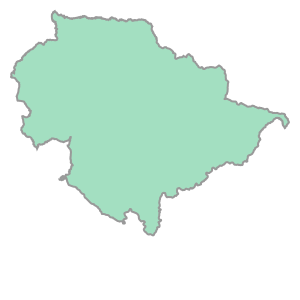

In [ ]:
# Unir los tres cantones en una sola geometría
area_estudio = limite.geometry.union_all()

print(area_estudio.geom_type)
area_estudio

### Tabla de pérdida de cobertura arbórea por cantón

La tabla muestra, para cada cantón, la pérdida acumulada de cobertura arbórea entre 2001 y 2025, la cobertura que existía en el año 2000 y el porcentaje de esa cobertura que se perdió.

Tarrazú perdió la mayor superficie (1 520 ha), pero León Cortés perdió la mayor proporción de su cobertura inicial (7,0 %), frente al 5,8 % de Tarrazú y el 2,5 % de Dota. El porcentaje permite comparar cantones de distinto tamaño, y muestra que la presión relativa fue mayor en León Cortés.

In [ ]:
# Pérdida media anual y máxima de cada cantón (agrupación sobre los 25 años)
anuales = loss.groupby("canton")["perdida_ha"].agg(
    media_anual_ha="mean", maximo_anual_ha="max"
).reset_index()

# Año en que ocurrió la mayor pérdida de cada cantón
pico = loss.loc[loss.groupby("canton")["perdida_ha"].idxmax(), ["canton", "anio"]]
pico = pico.rename(columns={"anio": "anio_pico"})

# Unir todo a la tabla resumen
resumen_completo = resumen.merge(anuales, on="canton").merge(pico, on="canton")

# Mostrar con formato
resumen_completo.style.format({
    "perdida_ha": "{:,.0f}",
    "cobertura_2000_ha": "{:,.0f}",
    "porcentaje_perdido": "{:.1f} %",
    "media_anual_ha": "{:,.1f}",
    "maximo_anual_ha": "{:,.1f}",
}).hide(axis="index")

canton,perdida_ha,cobertura_2000_ha,porcentaje_perdido,media_anual_ha,maximo_anual_ha,anio_pico
Tarrazú,"1,520","26,058",5.8 %,60.8,214.1,2009
Dota,952,"37,723",2.5 %,38.1,134.0,2017
León Cortés,700,"10,012",7.0 %,28.0,105.3,2009


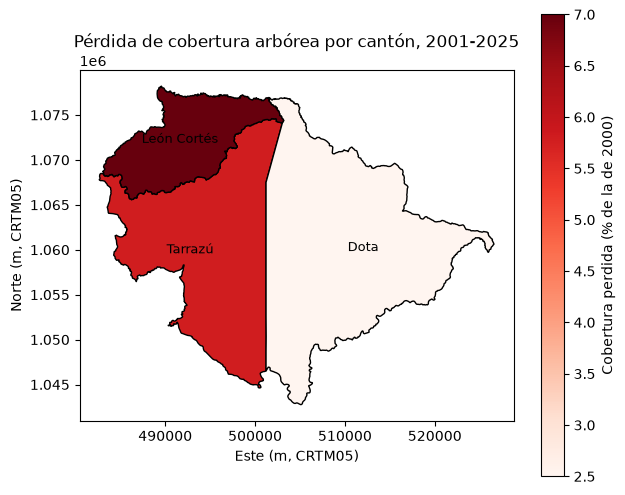

In [ ]:
# Mapa del porcentaje de cobertura perdida por cantón
fig, ax = plt.subplots(figsize=(7, 6))

# Dibujar los cantones coloreados según porcentaje_perdido
capa.plot(
    ax=ax,
    column="porcentaje_perdido",
    cmap="Reds",
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Cobertura perdida (% de la de 2000)"},
)

# Etiqueta con el nombre de cada cantón en su centro
for _, fila in capa.iterrows():
    punto = fila.geometry.representative_point()
    ax.annotate(fila["canton"], (punto.x, punto.y), ha="center", fontsize=9)

# Título y etiquetas de los ejes
ax.set_title("Pérdida de cobertura arbórea por cantón, 2001-2025")
ax.set_xlabel("Este (m, CRTM05)")
ax.set_ylabel("Norte (m, CRTM05)")
plt.show()

### Gráfico de barras agrupadas

El gráfico de barras agrupadas muestra la pérdida anual de cobertura arbórea (en hectáreas) de Dota, León Cortés y Tarrazú entre 2001 y 2025. Cada año del eje horizontal tiene tres barras, una por cantón, lo que permite comparar la magnitud de la pérdida entre cantones en un mismo año y ver cómo cambia a lo largo del periodo. Las barras más altas señalan los años de mayor pérdida.

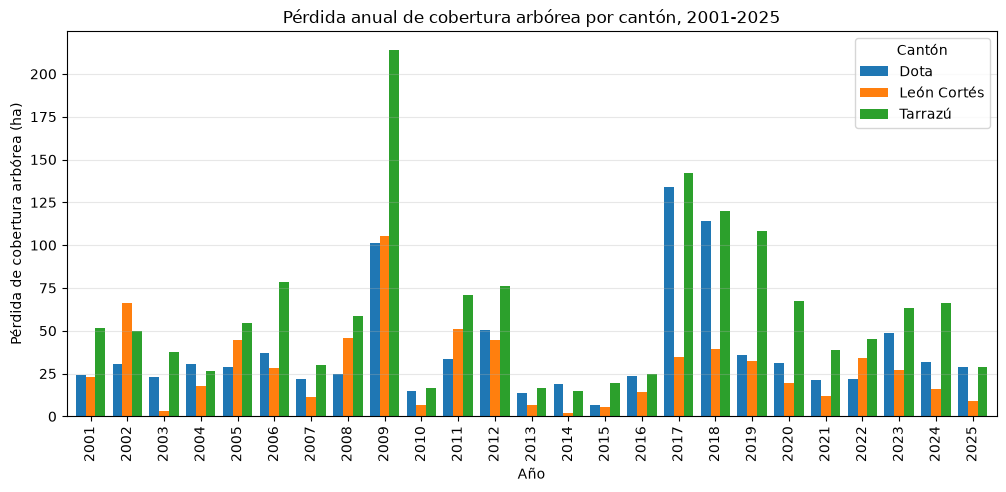

In [105]:
# Barras agrupadas: pérdida de cada cantón en cada año
fig, ax = plt.subplots(figsize=(12, 5))

anual.plot(kind="bar", ax=ax, width=0.8)

ax.set_title("Pérdida anual de cobertura arbórea por cantón, 2001-2025")
ax.set_xlabel("Año")
ax.set_ylabel("Pérdida de cobertura arbórea (ha)")
ax.legend(title="Cantón")
ax.grid(axis="y", alpha=0.3)

plt.show()

### Grafico de lineas

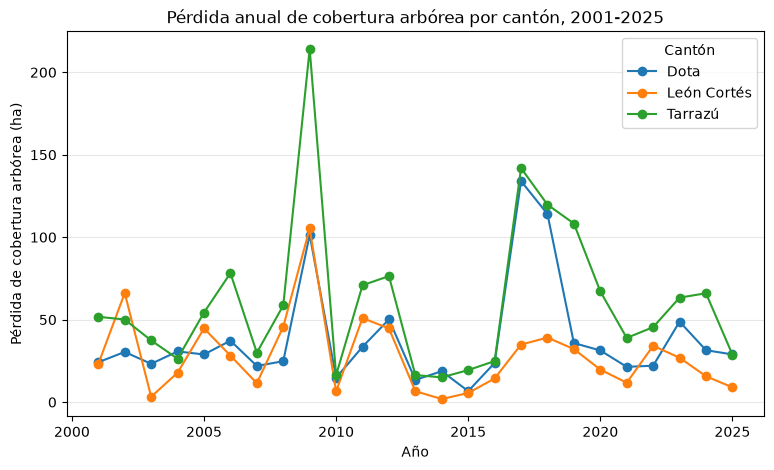

In [107]:
from matplotlib.ticker import StrMethodFormatter

# Tabla ancha: una fila por año, una columna por cantón
anual = loss.pivot_table(index="anio", columns="canton", values="perdida_ha", aggfunc="sum")

# Pérdida anual de cobertura arbórea por cantón, 2001-2025
fig, ax = plt.subplots(figsize=(9, 5))

anual.plot(kind="line", ax=ax, marker="o")

ax.set_title("Pérdida anual de cobertura arbórea por cantón, 2001-2025")
ax.set_xlabel("Año")
ax.set_ylabel("Pérdida de cobertura arbórea (ha)")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(title="Cantón")
ax.grid(axis="y", alpha=0.3)  # cuadrícula horizontal, tenue

plt.show()

### Histograma: distribución de la pérdida anual

El histograma muestra cuántas observaciones (un cantón en un año) caen en cada intervalo de pérdida anual de cobertura arbórea, con los tres cantones juntos (75 datos). La mayoría de los valores se concentra en pérdidas bajas: la mediana es de 30,7 ha y tres cuartas partes de las observaciones están por debajo de 50,6 ha. La media (42,3 ha) supera a la mediana y el máximo llega a 214,1 ha, por lo que la distribución es asimétrica hacia la derecha: la pérdida típica es moderada, pero unos pocos años de pérdida muy alta elevan el promedio.

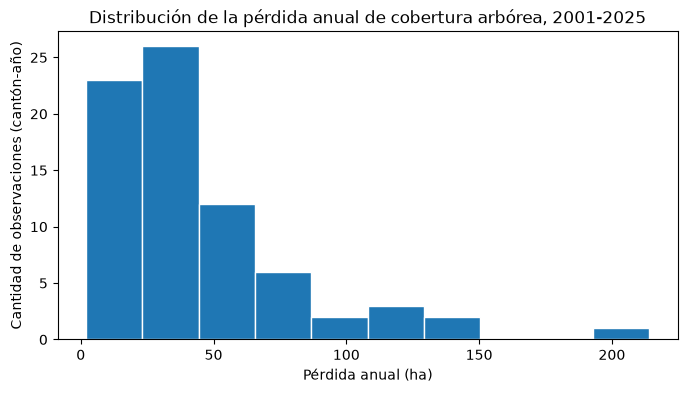

In [109]:
from matplotlib.ticker import StrMethodFormatter

# Color de las barras (en el ejemplo del curso viene definido antes)
AZUL = "#1f77b4"

# Distribución de la pérdida anual de cobertura arbórea
fig, ax = plt.subplots(figsize=(8, 4))

loss["perdida_ha"].plot(kind="hist", bins=10, ax=ax, color=AZUL, edgecolor="white")

ax.set_title("Distribución de la pérdida anual de cobertura arbórea, 2001-2025")
ax.set_xlabel("Pérdida anual (ha)")
ax.set_ylabel("Cantidad de observaciones (cantón-año)")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

plt.show()

### Conclusiones: las respuestas a las preguntas de la introducción y sus limitaciones.

1. ¿Qué cantón perdió más superficie de cobertura arbórea entre 2001 y 2025, y cuál perdió la mayor proporción de la que tenía en el año 2000?

Tarrazú perdió la mayor superficie (1 520 ha entre 2001 y 2025), seguido de Dota (952 ha) y León Cortés (700 ha). Sin embargo, León Cortés perdió la mayor proporción de su cobertura del año 2000 (7,0 %), frente al 5,8 % de Tarrazú y el 2,5 % de Dota.

2. ¿Cómo evolucionó la pérdida anual de cobertura arbórea en cada cantón durante el periodo?

Entre 2001 y 2025, Tarrazú presentó los picos más altos de pérdida de cobertura arbórea; el mayor ocurrió en [año] y alcanzó cerca de 200 ha en un solo año. Dota registró una pérdida acumulada cercana a la de Tarrazú, pero con una evolución más estable y sin picos tan marcados. León Cortés tuvo las menores pérdidas en hectáreas, aunque, por su menor tamaño, es el cantón con la mayor proporción de cobertura perdida (7,0 %).

3. ¿Cómo se distribuye la pérdida anual y existen años con pérdidas excepcionalmente altas?

La distribución es asimétrica hacia la derecha: la mediana es de 30,7 ha, el 75 % de las observaciones está por debajo de 50,6 ha y la media (42,3 ha) es mayor que la mediana. Sí existen años excepcionales: el máximo llega a 214,1 ha, un valor unas cuatro veces mayor que la mediana. Esto indica que, en la mayoría de los años, la pérdida de cobertura arbórea es moderada, y que unos pocos eventos puntuales de pérdida alta elevan el promedio y explican la cola de la distribución.


## Fuente de los datos 

Global Forest Watch. (2026). *Tree cover loss in Dota, León Cortés Castro y Tarrazú, San José, Costa Rica* [Conjunto de datos]. World Resources Institute. Recuperado el 7 de octubre de 2026, de https://www.globalforestwatch.org

Hansen, M. C., Potapov, P. V., Moore, R., Hancher, M., Turubanova, S. A., Tyukavina, A., Thau, D., Stehman, S. V., Goetz, S. J., Loveland, T. R., Kommareddy, A., Egorov, A., Chini, L., Justice, C. O., & Townshend, J. R. G. (2013). High-resolution global maps of 21st-century forest cover change. *Science, 342*(6160), 850-853. https://doi.org/10.1126/science.1244693

Global Administrative Areas. (2018). *GADM database of Global Administrative Areas* (Versión 3.6) [Conjunto de datos]. https://gadm.org

## Declaración de uso de asistentes de inteligencia artificial

Para este trabajo utilicé el asistente Claude (Anthropic). Lo usé para explicar funciones de pandas y matplotlib (`groupby`, `merge`, `concat`, `sort_values`), para generar y depurar el código de la carga de datos, la tabla resumen y los tres gráficos, y para ayudar a redactar la introducción, los párrafos de interpretación y el formato de las referencias. Revisé y ejecuté todo el código, comprobé los resultados contra los datos (por ejemplo, la pérdida total de Dota frente a lo reportado por Global Forest Watch), y puedo explicar cada parte de este cuaderno.